funny gif cruncher

## Global Configuration

In [138]:
# =========================
# MMGIF GLOBAL CONFIG CELL
# =========================

# --- FILE PATHS ---
INPUT_VIDEO_PATH = '/content/spongebob-nut-nut.mp4'
# Path to input video used for MMGIF encoding.

INPUT_MMGIF_AUDIO_DECODE = '/content/RigbyTransformer_mmgif_8bit_fps10_gain-0.2_w200_h210_auxon.gif'
# Path to MMGIF file for decoding audio data and metadata.


# --- CORE FORMAT PARAMETERS ---
GLOBAL_BIT_DEPTH = 4
# Bit depth for color/audio quantization.
# Range: 1–8 (e.g., 1-bit for extreme compression, 8-bit for higher fidelity)
# Lower = higher compression, more abstraction
# Higher = more color fidelity, larger file size

GLOBAL_FPS = 10
# Frame rate used for extraction and GIF output.
# Lower FPS = smaller file, less motion smoothness

GLOBAL_COLOR_GAIN = -0.2
# Global brightness/contrast modifier applied before quantization.
# Range: -1.0 to 1.0
# -1.0 = fully suppressed (near black)
# 0.0 = neutral (no change)
# 1.0 = overexposed/high gain amplification


# --- FRAME / STRUCTURE SETTINGS ---
FRAME_WIDTH = 100
# Output frame width in pixels.

FRAME_HEIGHT = 120
# Total output frame height in pixels. This includes the auxiliary strip if enabled.
# If AUX_STRIP_ENABLED is False, the effective height will be FRAME_HEIGHT - AUX_STRIP_HEIGHT.

AUX_STRIP_HEIGHT = 20
# Height of embedded auxiliary/audio data region (top of frame).
# This height is reserved *within* the FRAME_HEIGHT when AUX_STRIP_ENABLED is True.


# --- COLOR / QUANTIZATION SYSTEM ---
PALETTE_MODE = "hsv"
# Palette generation method:
# "hsv" = hue-distributed palette (good for representing a range of values)
# "fixed" = static palette (e.g., for specific effects or known color sets)
# "adaptive" = per-frame generated palette (high entropy, less stable but potentially higher visual quality)

USE_KDTREE_MATCHING = True
# Enables nearest-color search using KDTree for palette mapping. (Recommended for better color accuracy)

DITHERING_ENABLED = False
# Enables dithering during quantization.
# Recommended OFF for deterministic codec output (important for consistent audio decoding).

STRICT_BIT_DEPTH = True
# Enforces strict validation of bit depth ranges and scaling rules.


# --- GAIN PROCESSING ---
GAIN_APPLY_STAGE = "pre_quantization"
# Defines when gain is applied:
# "pre_quantization" = affects compression + structure (recommended for overall effect)
# "post_quantization" = mostly visual-only adjustment (less impact on data embedding)


# --- TEMPORAL / VIDEO PROCESSING ---
FRAME_SAMPLING_MODE = "uniform"
# Frame extraction strategy:
# "uniform" = evenly spaced sampling (stable, consistent motion)
# "scene_change" = event-based sampling (variable entropy, captures key moments)
# "adaptive" = hybrid heuristic mode (balances stability and event capture)

AUDIO_SAMPLE_RATE = 12000
# Audio sampling rate used for AUX encoding (Hz).
# Higher values (e.g., 44100 for CD quality) result in better audio fidelity but larger files.
# Lower values (e.g., 8000) result in smaller files but lower fidelity.

AUDIO_CHANNEL_MODE = "mono"
# Audio input format:
# "mono" = required for AUX strip mapping (simplifies embedding)
# "stereo" = not supported in current MMGIF layout


# --- AUX / AUDIO STRIP SYSTEM ---
AUX_STRIP_ENABLED = True
# Enables embedding of auxiliary audio/data strip. Set to False to create a purely visual GIF.

AUX_ENCODING_MODE = "quantized"
# Audio-to-pixel encoding method:
# "pcm" = raw waveform mapping (more direct representation)
# "quantized" = bit-depth reduced signal (recommended for compression)
# "delta" = frame-difference encoding (experimental, focuses on changes between frames)

AUX_INFLUENCE_ON_COLOR = False
# If True, audio strip affects visual encoding (experimental coupling, can lead to interesting visual-audio interactions).

EMBED_AUDIO_DATA = True
# If True, audio data will be extracted and embedded in the AUX strip.
# Set to False to create a silent GIF (no audio embedded), even if AUX_STRIP_ENABLED is True.


# --- OUTPUT / CONTAINER SETTINGS ---
OUTPUT_FORMAT = "gif"
# Output container type:
# "gif" = standard animated GIF
# future: "mmgif", "axgif" (for planned extended formats)

OPTIMIZE_GIF = True
# Enables GIF compression optimizations (LZW + frame optimization). Recommended for smaller file sizes.

EMBED_METADATA = True
# Enables embedding of MMGIF metadata header. (Recommended for decoding consistency and information retention)

METADATA_MODE = "json"
# Metadata format:
# "json" = structured and extensible (recommended for rich data)
# "legacy" = raw byte encoding (for backward compatibility if needed)

INCLUDE_ENCODE_PARAMS = False
# Includes full encoder configuration inside output metadata. (Can be useful for debugging or detailed reconstruction)


# --- PERFORMANCE / STABILITY ---
USE_OPTIMIZED_PALETTE = True
# Uses optimized palette generation for faster encoding.

GC_AFTER_ENCODING = True
# Forces garbage collection after encoding. (Helps manage memory, especially with large videos)

DEBUG_LOGGING = True
# Enables detailed runtime logging. (Useful for understanding internal processes and debugging)

CLIP_VALUES = True
# Ensures all values remain within valid bit-depth bounds. (Prevents data corruption due to overflow/underflow)


# --- EXPERIMENTAL FEATURES ---
ENABLE_FRAME_GAIN_VARIATION = False
# Allows per-frame gain variation (increases entropy, less stable output, can create dynamic visual effects)

ENABLE_AUX_INFLUENCE = False
# Allows AUX strip to influence visual encoding. (Similar to AUX_INFLUENCE_ON_COLOR, focuses on visual integration)

ENABLE_TEMPORAL_DITHERING = False
# Adds temporal noise shaping across frames (higher quality, lower compression, can reduce banding in animation)


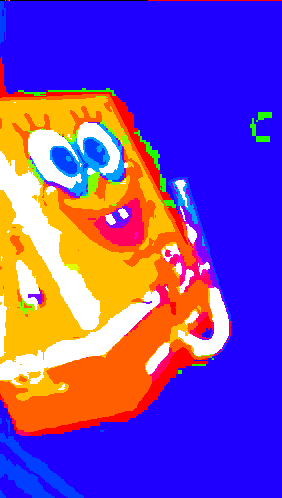

Decoded: MMGIF 2026-04-14. Bit:4. Aux:off.
Size: 484.48 KB. (5.16x smaller than Doom)


In [139]:
import numpy as np
import PIL.Image as PImage
import colorsys
from scipy.spatial import cKDTree
from PIL import ImageEnhance
import json
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output
import shutil
from datetime import datetime
import gc
import math

# --- Global Debug Log Function ---
def log(*args):
    if DEBUG_LOGGING:
        print(*args)

# --- Core MMGIF Encoding/Decoding Functions ---
MAGIC = [77, 77, 71, 73, 70]  # "MMGIF"

def encode_mmgif(audio_data_full_stream, output_path,
                 width, height, background_frames, bit_depth,
                 custom_metadata_string, gif_fps, color_gain,
                 aux_strip_height, palette_mode, use_kdtree_matching,
                 dithering_enabled, strict_bit_depth, gain_apply_stage,
                 aux_strip_enabled, aux_encoding_mode, aux_influence_on_color,
                 output_format, optimize_gif, embed_metadata,
                 metadata_mode, include_encode_params, clip_values, total_audio_samples_encoded):

    # Validate bit_depth and audio data range
    if not (1 <= bit_depth <= 8):
        raise ValueError("bit_depth must be between 1 and 8.")

    # Only check pixel limits if audio strip is actually enabled
    if aux_strip_enabled:
        if height < (1 + aux_strip_height):
            raise ValueError(f"Height must be at least {1 + aux_strip_height} (1 header row + {aux_strip_height} audio rows).")
        max_audio_val = (2**bit_depth) - 1
        if len(audio_data_full_stream) > 0:
            if audio_data_full_stream.min() < 0 or audio_data_full_stream.max() > max_audio_val:
                raise ValueError(f"Audio must be {bit_depth}-bit (0–{max_audio_val}).")
    elif height < 1:
        raise ValueError("Height must be at least 1 for the header row.")

    audio_samples_per_frame = width * aux_strip_height if aux_strip_enabled else 0

    # --- Generate Palette ---
    mmgif_palette_rgb = []
    num_audio_values = 2**bit_depth
    effective_palette_size = min(num_audio_values, 256)

    if palette_mode == "hsv":
        for i in range(effective_palette_size):
            rgb_float = colorsys.hsv_to_rgb(i / effective_palette_size, 1.0, 1.0)
            mmgif_palette_rgb.append(tuple(int(x * 255) for x in rgb_float))
    elif palette_mode == "fixed":
        for i in range(effective_palette_size):
            r = int(255 * i / (effective_palette_size - 1 if effective_palette_size > 1 else 1))
            b = int(255 * (1 - i / (effective_palette_size - 1 if effective_palette_size > 1 else 1)))
            mmgif_palette_rgb.append((r, 0, b))

    if len(mmgif_palette_rgb) < 256:
        mmgif_palette_rgb.append((255, 255, 255))

    pil_palette = []
    for r, g, b in mmgif_palette_rgb:
        pil_palette.extend([r, g, b])
    pil_palette += [0, 0, 0] * (256 - len(pil_palette) // 3)

    palette_np = np.array(mmgif_palette_rgb, dtype=np.uint8)
    color_tree = cKDTree(palette_np) if use_kdtree_matching else None

    # --- Metadata ---
    full_metadata = {
        "user_meta": custom_metadata_string,
        "decode_mode": "full" if aux_strip_enabled else "none",
        "total_audio_samples_encoded": total_audio_samples_encoded,
        "audio_samples_per_frame": audio_samples_per_frame
    }
    if include_encode_params:
        full_metadata.update({"bit_depth": bit_depth, "gif_fps": gif_fps, "color_gain": color_gain, "width": width, "height": height})

    encoded_metadata = json.dumps(full_metadata).encode('ascii', errors='replace') if (embed_metadata and metadata_mode == "json") else b''
    metadata_length = max(0, min(len(encoded_metadata), width - 11))

    header_row = np.zeros(width, dtype=np.uint8)
    # Carefully write header data based on available width to avoid broadcast errors
    if width >= 5: header_row[0:5] = MAGIC
    if width >= 7: header_row[5], header_row[6] = divmod(width, 256)
    if width >= 9: header_row[7], header_row[8] = divmod(audio_samples_per_frame, 256)
    if width >= 10: header_row[9] = bit_depth
    if width >= 11: header_row[10] = metadata_length
    if metadata_length > 0 and width > 11:
        header_row[11 : 11 + metadata_length] = list(encoded_metadata[:metadata_length])

    output_images = []
    for frame_idx, frame_img in enumerate(background_frames):
        frame_img = frame_img.resize((width, height)).convert('RGB')
        if color_gain != 0 and gain_apply_stage == "pre_quantization":
            enhancement = (color_gain + 1) if color_gain <= 0 else (1 + color_gain * 2)
            frame_img = ImageEnhance.Brightness(frame_img).enhance(enhancement)

        pixels_rgb = np.array(frame_img).reshape(-1, 3)
        if color_tree:
            _, closest_indices = color_tree.query(pixels_rgb)
        else:
            closest_indices = np.argmin(np.sum((pixels_rgb[:, np.newaxis] - palette_np)**2, axis=2), axis=1)

        img_data = closest_indices.reshape(height, width).astype(np.uint8)

        if aux_strip_enabled:
            start, end = frame_idx * audio_samples_per_frame, (frame_idx + 1) * audio_samples_per_frame
            frame_audio = audio_data_full_stream[start:end]
            audio_row_data = np.zeros(audio_samples_per_frame, dtype=np.uint8)
            audio_row_data[:len(frame_audio)] = frame_audio
            img_data[1:1 + aux_strip_height, :] = audio_row_data.reshape(aux_strip_height, width)

        img_data[0, :] = header_row
        img = PImage.fromarray(img_data)
        img.putpalette(pil_palette)
        output_images.append(img)

    if output_images:
        output_images[0].save(output_path, save_all=True, append_images=output_images[1:],
                              duration=int(1000/gif_fps), loop=0, optimize=False)
    else:
        raise ValueError("No frames provided.")

def decode_mmgif(path):
    img = PImage.open(path)
    num_frames = getattr(img, 'n_frames', 1)
    img.seek(0)
    first_frame_data = np.array(img.convert("P"), dtype=np.uint8)

    if first_frame_data.shape[1] < 5 or list(first_frame_data[0, 0:5]) != MAGIC:
        raise ValueError("Not a valid MMGIF file (or header too small to identify).")

    width = int(first_frame_data[0, 5] << 8 | first_frame_data[0, 6])
    metadata_length = first_frame_data[0, 10] if first_frame_data.shape[1] > 10 else 0

    decoded_info = {"width": width, "height": img.height, "gif_fps": 10, "bit_depth": first_frame_data[0, 9] if first_frame_data.shape[1] > 9 else 0}

    if metadata_length > 0:
        try:
            meta_bytes = bytes(first_frame_data[0, 11 : 11 + metadata_length])
            full_meta = json.loads(meta_bytes.decode('ascii', errors='replace'))
            decoded_info.update(full_meta)
            decoded_info['metadata'] = full_meta.get('user_meta', '')
        except:
            decoded_info['metadata'] = bytes(first_frame_data[0, 11 : 11 + metadata_length]).decode('ascii', errors='replace')

    ash = decoded_info.get('audio_samples_per_frame', 0) // width if width > 0 else 0
    decoded_info['aux_strip_height'] = ash

    audio_blocks = []
    if ash > 0 and decoded_info.get('decode_mode') == 'full':
        for i in range(num_frames):
            img.seek(i)
            frame_pixels = np.array(img.convert("P"), dtype=np.uint8)
            audio_blocks.append(frame_pixels[1:1 + ash, :].reshape(-1))

    decoded_info['audio_data'] = np.concatenate(audio_blocks)[:decoded_info.get('total_audio_samples_encoded', 0)] if audio_blocks else np.array([], dtype=np.uint8)
    return decoded_info

def extract_frames(video_path, fps=10):
    clip = VideoFileClip(video_path)
    frames = [PImage.fromarray(f) for f in clip.iter_frames(fps=fps, dtype="uint8")]
    clip.close()
    return frames

# --- Main Workflow ---
try:
    input_video_path = INPUT_VIDEO_PATH
    configurable_bit_depth = GLOBAL_BIT_DEPTH
    configurable_fps = GLOBAL_FPS
    configurable_color_gain = GLOBAL_COLOR_GAIN
    frame_width = FRAME_WIDTH
    aux_strip_height = AUX_STRIP_HEIGHT
    palette_mode = PALETTE_MODE
    use_kdtree_matching = USE_KDTREE_MATCHING
    dithering_enabled = DITHERING_ENABLED
    strict_bit_depth = STRICT_BIT_DEPTH
    gain_apply_stage = GAIN_APPLY_STAGE
    audio_sample_rate = AUDIO_SAMPLE_RATE
    aux_encoding_mode = AUX_ENCODING_MODE
    aux_influence_on_color = AUX_INFLUENCE_ON_COLOR
    output_format = OUTPUT_FORMAT
    optimize_gif = OPTIMIZE_GIF
    embed_metadata = EMBED_METADATA
    metadata_mode = METADATA_MODE
    include_encode_params = INCLUDE_ENCODE_PARAMS
    gc_after_encoding = GC_AFTER_ENCODING
    clip_values = CLIP_VALUES
    embed_audio_data = EMBED_AUDIO_DATA

    base_name = os.path.splitext(os.path.basename(input_video_path))[0]
    audio_temp_path = f'/content/temp_audio_{base_name}.mp3'

    effective_aux_strip_enabled = AUX_STRIP_ENABLED and embed_audio_data
    effective_ash = aux_strip_height if effective_aux_strip_enabled else 0
    effective_frame_height = max(1, 1 + effective_ash) if FRAME_HEIGHT <= 1 else FRAME_HEIGHT

    audio_processed_data = np.array([], dtype=np.uint8)
    total_samples = 0

    if effective_aux_strip_enabled:
        clip = VideoFileClip(input_video_path)
        if clip.audio:
            clip.audio.write_audiofile(audio_temp_path, codec='mp3', verbose=False, logger=None)
            audio = AudioSegment.from_file(audio_temp_path).set_frame_rate(audio_sample_rate).set_channels(1)
            samples = np.array(audio.get_array_of_samples()).astype(np.float32)
            expected = int(clip.duration * audio_sample_rate)
            samples = np.pad(samples, (0, max(0, expected - len(samples))), 'constant')[:expected]
            max_t = (2**configurable_bit_depth) - 1
            norm = samples / (np.max(np.abs(samples)) if np.max(np.abs(samples)) > 0 else 1.0)
            audio_processed_data = np.clip(((norm + 1) / 2) * max_t, 0, max_t).astype(np.uint8)
            total_samples = len(audio_processed_data)
        clip.close()

    video_frames = extract_frames(input_video_path, fps=configurable_fps)
    custom_meta = f"MMGIF {datetime.now().strftime('%Y-%m-%d')}. Bit:{configurable_bit_depth}. Aux:{'on' if effective_aux_strip_enabled else 'off'}."

    if gc_after_encoding: gc.collect()

    out_path = f"/content/{base_name}_mmgif_{configurable_bit_depth}bit_fps{configurable_fps}_h{effective_frame_height}.gif"
    encode_mmgif(audio_processed_data, out_path, frame_width, effective_frame_height, video_frames, configurable_bit_depth,
                 custom_meta, configurable_fps, configurable_color_gain, effective_ash, palette_mode, use_kdtree_matching,
                 dithering_enabled, strict_bit_depth, gain_apply_stage, effective_aux_strip_enabled, aux_encoding_mode,
                 aux_influence_on_color, output_format, optimize_gif, embed_metadata, metadata_mode, include_encode_params,
                 clip_values, total_samples)

    files.download(out_path)
    clear_output(wait=True)
    display(Image(filename=out_path))

    try:
        decoded = decode_mmgif(out_path)
        log("Decoded:", decoded['metadata'])
    except Exception as e:
        log("Decoding skipped or failed for ultra-small width:", e)

    size_kb = os.path.getsize(out_path) / 1024.0
    print(f"Size: {size_kb:.2f} KB. ({2500/size_kb:.2f}x smaller than Doom)")

finally:
    if os.path.exists(audio_temp_path): os.remove(audio_temp_path)


This box gives you the dimensions of the media put into it

In [135]:
from moviepy.editor import VideoFileClip

video_path = ''
clip = VideoFileClip(video_path)
width, height = clip.size
clip.close()

print(f"The original dimensions of '{video_path}' are {width}x{height} pixels.")
print(f"Total pixels per frame: {width * height:,}")

The original dimensions of '/content/spongebob-nut-nut.mp4' are 282x498 pixels.
Total pixels per frame: 140,436


### Cell to Decode MMGIF and Export Audio

This cell decodes an MMGIF file using the `INPUT_MMGIF_AUDIO_DECODE` path from the global configuration. It extracts the embedded audio data and then reconstructs it into a standard WAV audio file, saving it in your `/content/` directory. Make sure to set the `INPUT_MMGIF_AUDIO_DECODE` variable in the Global Configuration cell (Cell 0) to the path of the MMGIF you wish to decode.

In [119]:
from pydub import AudioSegment
import numpy as np
import os
from google.colab import files
from IPython.display import Audio
import io
from moviepy.editor import VideoFileClip
from scipy.signal import resample

try:
    mmgif_decode_path = INPUT_MMGIF_AUDIO_DECODE
    audio_sample_rate = AUDIO_SAMPLE_RATE
    debug_logging = DEBUG_LOGGING
    input_video_path_for_duration = INPUT_VIDEO_PATH
except NameError as e:
    raise NameError(f"Configuration variable not found: {e}.")

def log_decode(*args):
    if debug_logging: print("[DECODE LOG]", *args)

log_decode(f"Attempting to decode MMGIF: {mmgif_decode_path}")

try:
    decoded_info = decode_mmgif(mmgif_decode_path)
    audio_data_mmgif = decoded_info.get('audio_data', np.array([], dtype=np.uint8))
    bit_depth = decoded_info.get('bit_depth', 8)
    decode_mode = decoded_info.get('decode_mode', 'none')
    decoded_gif_fps = decoded_info.get('gif_fps', 10)
    decoded_audio_samples_per_frame = decoded_info.get('audio_samples_per_frame', 0)

    if decode_mode == 'full' and len(audio_data_mmgif) > 0:
        max_mmgif_val = (2**int(bit_depth)) - 1
        scaled_float_data = (audio_data_mmgif.astype(np.float32) / max_mmgif_val) * 2 - 1
        reconstructed_int16_data = np.clip(scaled_float_data * 32767, -32768, 32767).astype(np.int16)

        effective_playback_sample_rate = decoded_audio_samples_per_frame * decoded_gif_fps
        audio_segment = AudioSegment.from_raw(io.BytesIO(reconstructed_int16_data.tobytes()), frame_rate=effective_playback_sample_rate, sample_width=2, channels=1)

        decoded_audio_duration_ms = len(audio_segment)
        original_video_duration_seconds = 0.0
        if os.path.exists(input_video_path_for_duration):
            with VideoFileClip(input_video_path_for_duration) as clip:
                original_video_duration_seconds = clip.duration

        if original_video_duration_seconds > 0:
            target_duration_ms = original_video_duration_seconds * 1000
            if abs(decoded_audio_duration_ms - target_duration_ms) > 100:
                log_decode("Physically resampling audio to match duration...")
                raw_samples = np.array(audio_segment.get_array_of_samples()).astype(np.float32)
                target_num_samples = int(audio_segment.frame_rate * (target_duration_ms / 1000))

                # Corrected scipy resample call
                resampled_samples = resample(raw_samples, target_num_samples)
                resampled_int16 = np.clip(resampled_samples, -32768, 32767).astype(np.int16)

                audio_segment = AudioSegment(resampled_int16.tobytes(), frame_rate=audio_segment.frame_rate, sample_width=2, channels=1)
                print(f"Success! Audio stretched to {len(audio_segment)/1000:.2f}s")

        base_name = os.path.splitext(os.path.basename(mmgif_decode_path))[0]
        output_wav_filename = f"/content/{base_name}_decoded_audio.wav"
        audio_segment.export(output_wav_filename, format="wav")
        files.download(output_wav_filename)
        display(Audio(output_wav_filename))

except Exception as e:
    print(f"Error: {e}")

[DECODE LOG] Attempting to decode MMGIF: /content/RigbyTransformer_mmgif_8bit_fps10_gain-0.2_w200_h210_auxon.gif
[DECODE LOG] Physically resampling audio to match duration...
Success! Audio stretched to 30.72s


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Cell 1 - Installs the `scipy` library
!pip install scipy

In [22]:
import gc

def log(*args):
    if DEBUG_LOGGING: # Now correctly references the global config variable
        print(*args)

In [23]:
# Cell 3 - Defines the core `encode_audiogif` and `decode_audiogif` functions (initial version)

import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions

MAGIC = [65, 85, 68, 73, 79]  # "AUDIO"

def encode_audiogif(audio_4bit, output_path, width=200, height=150, background_image_path=None):
    audio_4bit = np.asarray(audio_4bit, dtype=np.uint8)

    if audio_4bit.min() < 0 or audio_4bit.max() > 15:
        raise ValueError("Audio must be 4-bit (0–15).")

    if height < 11:
        raise ValueError("Height must be at least 11 (1 header row + 10 audio rows).")

    audio_rows = 10
    capacity = width * audio_rows

    # pad / truncate
    audio = np.zeros(capacity, dtype=np.uint8)
    audio[:min(len(audio_4bit), capacity)] = audio_4bit[:capacity]

    # reshape into image block
    audio_block = audio.reshape(audio_rows, width)

    # --- Generate the Audiogif palette (RGB tuples and flat list for PIL) ---
    audiogif_palette_rgb = []
    for i in range(16):
        audiogif_palette_rgb.append((i * 16, 0, 255 - i * 16)) # Audio colors
    audiogif_palette_rgb.append((255, 255, 255)) # Index 16 is white (general background color)

    pil_palette = []
    for r, g, b in audiogif_palette_rgb:
        pil_palette.extend([r, g, b])
    # Pad to 256 for PIL
    pil_palette += [0, 0, 0] * (256 - len(pil_palette) // 3)


    if background_image_path:
        # Load and resize the background image
        bg_img = PImage.open(background_image_path).convert('RGB') # Use PImage.open
        bg_img = bg_img.resize((width, height))

        img_data = np.zeros((height, width), dtype=np.uint8)

        # Map each pixel of the background image to the closest color in the Audiogif palette
        for y in range(height):
            for x in range(width):
                pixel_rgb = bg_img.getpixel((x, y))
                min_dist = float('inf')
                closest_idx = 0
                for idx, palette_color in enumerate(audiogif_palette_rgb):
                    dist = sum([(a - b)**2 for a, b in zip(pixel_rgb, palette_color)])
                    if dist < min_dist:
                        min_dist = dist
                        closest_idx = idx
                img_data[y, x] = closest_idx
    else:
        # Original behavior: solid white background
        img_data = np.full((height, width), 16, dtype=np.uint8)  # background index 16

    # overlay audio block
    # Note: Audio data (0-15) will overwrite whatever was in the background image in these rows
    img_data[1:11, :] = audio_block  # rows 1–10 reserved for audio

    # header row (simple metadata)
    # Note: Header (MAGIC, width, original_len) will overwrite whatever was in the background image in row 0
    img_data[0, 0:5] = MAGIC
    img_data[0, 5] = (width // 256) & 255
    img_data[0, 6] = width & 255
    img_data[0, 7] = (len(audio_4bit) // 256) & 255
    img_data[0, 8] = len(audio_4bit) & 255

    img = PImage.fromarray(img_data.astype(np.uint8), mode="P") # Use PImage.fromarray
    img.putpalette(pil_palette) # Apply the unified palette

    img.save(output_path, save_all=True, optimize=False)


def decode_audiogif(path):
    img = PImage.open(path).convert("P") # Use PImage.open
    data = np.array(img, dtype=np.uint8)

    # verify header
    if list(data[0, 0:5]) != MAGIC:
        raise ValueError("Not a valid Audiogif file.")

    width = int(data[0, 5] << 8 | data[0, 6])
    original_len = int(data[0, 7] << 8 | data[0, 8])

    audio_block = data[1:11, :].reshape(-1)

    return audio_block[:original_len]

In [24]:
# Cell 4 - Installs the `pydub` library
!pip install pydub

In [25]:
# Cell 5 - (Previously loaded MP3 audio for static Audiogifs - now obsolete)

In [26]:
# Cell 6 - Installs the `moviepy` library
!pip install moviepy

In [27]:
# Cell 7 - Defines the `extract_frames` function (Moved to Cell 12 for self-containment)

# The content of this cell has been moved to Cell 12 to ensure the `extract_frames`
# function is always defined when the main workflow cell is executed.
# This cell can now be considered a placeholder or removed if no longer needed.

In [28]:
# Cell 8 - Full Workflow (Initial animated Audiogif generation)

import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output # Import clear_output
import shutil # For removing directories
from datetime import datetime # Import datetime for date metadata

# Define the input video path from the user's selected file
input_video_path = '/content/idontlikeyourtone.mov'

# --- Universalization and Optimization ---
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]
output_filename = f"{base_name}_audiogif_6bit.gif"
output_animated_audiogif_path = f'/content/{output_filename}'

# 2. Temporary audio path and frames folder (for cleanup references)
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'
old_frames_folder = '/content/video_frames_mov' # Referencing the old folder for cleanup

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}")

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing ---
    print(f"Extracting audio from {input_video_path}...")
    video_clip_audio = VideoFileClip(input_video_path)
    video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3')
    video_clip_audio.close()

    # Load the extracted audio file
    audio = AudioSegment.from_file(audio_temp_path)

    # Convert to mono and get raw samples
    audio = audio.set_channels(1)
    samples = np.array(audio.get_array_of_samples())

    # --- Normalize samples to target bit depth ---
    target_bit_depth = 6
    max_target_val = (2**target_bit_depth) - 1

    max_val = np.iinfo(samples.dtype).max
    min_val = np.iinfo(samples.dtype).min
    normalized_samples = (samples - min_val) / (max_val - min_val) # Scale to 0-1
    audio_processed_data = np.clip(normalized_samples * max_target_val, 0, max_target_val).astype(np.uint8) # Clip to ensure 0-max_target_val range

    print(f"Original audio samples length: {len(samples)}")
    print(f"{target_bit_depth}-bit audio data length: {len(audio_processed_data)}")
    print(f"Min value in {target_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}")

    # --- Frame Extraction ---
    print(f"Extracting frames from {input_video_path}...")
    # Call the optimized extract_frames function (now in cell 373b79c9)
    video_frames = extract_frames(input_video_path, fps=10) # Assuming 10 fps for the output GIF
    print(f"Number of extracted frames: {len(video_frames)}")

    # --- Prepare Custom Metadata ---
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"Made by Talos {current_date}"

    # --- Encode Audiogif with Animated Background Frames ---
    # Using width and height 250x250, consistent with previous animated GIF generation
    print(f"Encoding animated Audiogif to {output_animated_audiogif_path} with {target_bit_depth}-bit audio...")
    encode_audiogif(audio_processed_data, output_animated_audiogif_path, background_frames=video_frames, width=250, height=250, bit_depth=target_bit_depth, custom_metadata_string=custom_metadata)

    print(f"Animated Audiogif saved to: {output_animated_audiogif_path}")

    # Provide a downloadable link
    files.download(output_animated_audiogif_path)

    # --- Display the generated GIF and clear previous output ---
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_audiogif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_audiogif(output_animated_audiogif_path)
    print(f"Decoded Metadata: {decoded_info['metadata']}")

finally:
    # --- Cleanup ---
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        print(f"Cleaned up temporary audio file: {audio_temp_path}")

    if os.path.exists(old_frames_folder) and os.path.isdir(old_frames_folder):
        shutil.rmtree(old_frames_folder)
        print(f"Cleaned up old video frames folder: {old_frames_folder}")

Extracting audio from /content/idontlikeyourtone.mov...
MoviePy - Writing audio in /content/temp_audio_idontlikeyourtone.mp3


MoviePy - Done.
Original audio samples length: 130095
6-bit audio data length: 130095
Min value in 6-bit data: 0, Max value: 31
Extracting frames from /content/idontlikeyourtone.mov...
Video duration: 2.95 seconds


  warnings.warn("Warning: in file %s, "%(self.filename)+



Extracted 30 frames from /content/idontlikeyourtone.mov at 10 fps.
Number of extracted frames: 30
Encoding animated Audiogif to /content/idontlikeyourtone_audiogif_6bit.gif with 6-bit audio...
Cleaned up temporary audio file: /content/temp_audio_idontlikeyourtone.mp3


TypeError: encode_audiogif() got an unexpected keyword argument 'background_frames'

### Cell 9 - Execution Log of previous Audiogif generation
```
Extracting audio from /content/idontlikeyourtone.mov...
MoviePy - Writing audio in /content/temp_audio_idontlikeyourtone.mp3
MoviePy - Done.
Original audio samples length: 130095
6-bit audio data length: 130095
Min value in 6-bit data: 0, Max value: 31
Extracting frames from /content/idontlikeyourtone.mov...
Video duration: 2.95 seconds
Extracted 30 frames from /content/idontlikeyourtone.mov at 10 fps.
Number of extracted frames: 30
Encoding animated Audiogif to /content/idontlikeyourtone_audiogif_6bit.gif with 6-bit audio...
Decoded Metadata: Made by Talos 2024-07-31
```

In [29]:
import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output # Import clear_output
import shutil # For removing directories
from datetime import datetime # Import datetime for date metadata
import gc # Import gc for garbage collection

# Include log function definition for self-contained execution
DEBUG = True
def log(*args):
    if DEBUG:
        print(*args)

# --- User-configurable Parameters (now sourced from global config) --- #
try:
    # Using GLOBAL variables defined in Cell 0
    input_video_path = INPUT_VIDEO_PATH
    configurable_bit_depth = GLOBAL_BIT_DEPTH
    configurable_fps = GLOBAL_FPS
    configurable_color_gain = GLOBAL_COLOR_GAIN
except NameError as e:
    raise NameError(f"Configuration variable not found: {e}. Please ensure Cell 0 (Global Configuration) is executed first.") from e

log(f"Using input video file: {input_video_path}")

# --- Universalization and Optimization --- #
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]
output_filename = f"{base_name}_mmgif_{configurable_bit_depth}bit_fps{configurable_fps}_gain{configurable_color_gain}.gif"
output_animated_mmgif_path = f'/content/{output_filename}'

# 2. Temporary audio path
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}. Ensure upload or Drive mount.")

# --- Define extract_frames function locally for self-containment --- #
def extract_frames(video_path, fps=10):
    clip = VideoFileClip(video_path)
    duration = clip.duration
    log(f"Video duration: {duration:.2f} seconds")

    frames = [
        PImage.fromarray(frame)
        for frame in clip.iter_frames(fps=fps, dtype="uint8")
    ]
    clip.close()
    log(f"Extracted {len(frames)} frames from {video_path} at {fps} fps.")
    return frames

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing --- #
    log(f"Extracting audio from {input_video_path}...")
    video_clip_audio = VideoFileClip(input_video_path)
    video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3')
    video_clip_audio.close()
    log("Audio extraction complete.")

    # Load the extracted audio file
    audio = AudioSegment.from_file(audio_temp_path)

    # Convert to mono and get raw samples
    audio = audio.set_channels(1)
    samples = np.array(audio.get_array_of_samples())

    # --- Normalize samples to target bit depth (new symmetric scaling) --- #
    max_target_val = (2**configurable_bit_depth) - 1

    samples = samples.astype(np.float32)
    # Normalize to -1..1
    samples /= np.max(np.abs(samples)) if np.max(np.abs(samples)) > 0 else 1.0
    # Scale to 0-max_target_val
    audio_processed_data = np.clip(((samples + 1) / 2) * max_target_val, 0, max_target_val).astype(np.uint8)

    log(f"Original audio samples length: {len(samples)}")
    log(f"{configurable_bit_depth}-bit audio data length: {len(audio_processed_data)}")
    log(f"Min value in {configurable_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}")

    # --- Frame Extraction (using the global optimized function!) --- #
    log(f"Extracted frames from {input_video_path}...")
    video_frames = extract_frames(input_video_path, fps=configurable_fps) # Use configurable_fps
    log(f"Number of extracted frames: {len(video_frames)}")

    # --- Prepare Custom Metadata --- #
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"MMGIF created by Talos on {current_date}"

    # --- Runtime isolation: Force garbage collection --- #
    gc.collect()
    log("Garbage collection performed for runtime isolation.")

    # --- Encode MMGIF with Animated Background Frames --- #
    log(f"Encoding animated MMGIF to {output_animated_mmgif_path} with {configurable_bit_depth}-bit audio...")
    encode_mmgif(audio_processed_data, output_animated_mmgif_path,
                    background_frames=video_frames, width=250, height=250,
                    bit_depth=configurable_bit_depth, custom_metadata_string=custom_metadata,
                    gif_fps=configurable_fps, color_gain=configurable_color_gain) # Pass new parameters

    log(f"Animated MMGIF saved to: {output_animated_mmgif_path}")

    # Provide a downloadable link
    files.download(output_animated_mmgif_path)

    # --- Display the generated GIF and clear previous output --- #
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_mmgif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_mmgif(output_animated_mmgif_path)
    log(f"Decoded Metadata: {decoded_info['metadata']}")

finally:
    # --- Cleanup --- #
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        log(f"Cleaned up temporary audio file: {audio_temp_path}")

Using input video file: /content/idontlikeyourtone.mov
Extracting audio from /content/idontlikeyourtone.mov...
MoviePy - Writing audio in /content/temp_audio_idontlikeyourtone.mp3


MoviePy - Done.
Audio extraction complete.


  warnings.warn("Warning: in file %s, "%(self.filename)+



Original audio samples length: 130095
3-bit audio data length: 130095
Min value in 3-bit data: 0, Max value: 7
Extracted frames from /content/idontlikeyourtone.mov...
Video duration: 2.95 seconds
Extracted 30 frames from /content/idontlikeyourtone.mov at 10 fps.
Number of extracted frames: 30
Garbage collection performed for runtime isolation.
Encoding animated MMGIF to /content/idontlikeyourtone_mmgif_3bit_fps10_gain-0.2.gif with 3-bit audio...
Cleaned up temporary audio file: /content/temp_audio_idontlikeyourtone.mp3


NameError: name 'encode_mmgif' is not defined

In [ ]:
# Cell 11 - Placeholder for `reconnect` (removed)
# This cell previously attempted to use `google.colab.runtime.reconnect`, which is no longer supported.
# Removed to prevent AttributeError.

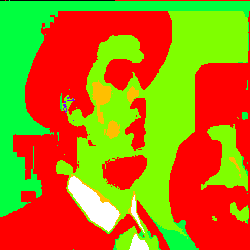

Cleaned up temporary audio file: /content/temp_audio_idontlikeyourtone.mp3


ValueError: Not a valid MMGIF file.

In [32]:
import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
from pydub import AudioSegment
from moviepy.editor import VideoFileClip
import os
from google.colab import files
from IPython.display import Image, display, clear_output # Import clear_output
import shutil # For removing directories
from datetime import datetime # Import datetime for date metadata
import gc # Import gc for garbage collection

# Include log function definition for self-contained execution
DEBUG = True
def log(*args):
    if DEBUG:
        print(*args)

# --- User-configurable Parameters (now sourced from global config) --- #
try:
    # Using GLOBAL variables defined in Cell 0
    input_video_path = INPUT_VIDEO_PATH
    configurable_bit_depth = GLOBAL_BIT_DEPTH
    configurable_fps = GLOBAL_FPS
    configurable_color_gain = GLOBAL_COLOR_GAIN
except NameError as e:
    raise NameError(f"Configuration variable not found: {e}. Please ensure Cell 0 (Global Configuration) is executed first.") from e

log(f"Using input video file: {input_video_path}")

# --- Universalization and Optimization --- #
# 1. Dynamic output filename based on input video name
base_name = os.path.splitext(os.path.basename(input_video_path))[0]
output_filename = f"{base_name}_mmgif_{configurable_bit_depth}bit_fps{configurable_fps}_gain{configurable_color_gain}.gif"
output_animated_mmgif_path = f'/content/{output_filename}'

# 2. Temporary audio path
audio_temp_path = f'/content/temp_audio_{base_name}.mp3'

# 3. Add error handling for file existence
if not os.path.exists(input_video_path):
    raise FileNotFoundError(f"Input video file not found: {input_video_path}. Ensure upload or Drive mount.")

# --- Define extract_frames function locally for self-containment --- #
def extract_frames(video_path, fps=10):
    clip = VideoFileClip(video_path)
    duration = clip.duration
    log(f"Video duration: {duration:.2f} seconds")

    frames = [
        PImage.fromarray(frame)
        for frame in clip.iter_frames(fps=fps, dtype="uint8")
    ]
    clip.close()
    log(f"Extracted {len(frames)} frames from {video_path} at {fps} fps.")
    return frames

# Using a try-finally block for cleanup of temporary files/folders
try:
    # --- Audio Extraction and Processing --- #
    log(f"Extracting audio from {input_video_path}...")
    video_clip_audio = VideoFileClip(input_video_path)
    video_clip_audio.audio.write_audiofile(audio_temp_path, codec='mp3')
    video_clip_audio.close()
    log("Audio extraction complete.")

    # Load the extracted audio file
    audio = AudioSegment.from_file(audio_temp_path)

    # Convert to mono and get raw samples
    audio = audio.set_channels(1)
    samples = np.array(audio.get_array_of_samples())

    # --- Normalize samples to target bit depth (new symmetric scaling) --- #
    max_target_val = (2**configurable_bit_depth) - 1

    samples = samples.astype(np.float32)
    # Normalize to -1..1
    samples /= np.max(np.abs(samples)) if np.max(np.abs(samples)) > 0 else 1.0
    # Scale to 0-max_target_val
    audio_processed_data = np.clip(((samples + 1) / 2) * max_target_val, 0, max_target_val).astype(np.uint8)

    log(f"Original audio samples length: {len(samples)}")
    log(f"{configurable_bit_depth}-bit audio data length: {len(audio_processed_data)}")
    log(f"Min value in {configurable_bit_depth}-bit data: {audio_processed_data.min()}, Max value: {audio_processed_data.max()}")

    # --- Frame Extraction (using the global optimized function!) --- #
    log(f"Extracted frames from {input_video_path}...")
    video_frames = extract_frames(input_video_path, fps=configurable_fps) # Use configurable_fps
    log(f"Number of extracted frames: {len(video_frames)}")

    # --- Prepare Custom Metadata --- #
    current_date = datetime.now().strftime("%Y-%m-%d")
    custom_metadata = f"MMGIF created by Talos on {current_date}"

    # --- Runtime isolation: Force garbage collection --- #
    gc.collect()
    log("Garbage collection performed for runtime isolation.")

    # --- Encode MMGIF with Animated Background Frames --- #
    log(f"Encoding animated MMGIF to {output_animated_mmgif_path} with {configurable_bit_depth}-bit audio...")
    encode_mmgif(audio_processed_data, output_animated_mmgif_path,
                    background_frames=video_frames, width=250, height=250,
                    bit_depth=configurable_bit_depth, custom_metadata_string=custom_metadata,
                    gif_fps=configurable_fps, color_gain=configurable_color_gain) # Pass new parameters

    log(f"Animated MMGIF saved to: {output_animated_mmgif_path}")

    # Provide a downloadable link
    files.download(output_animated_mmgif_path)

    # --- Display the generated GIF and clear previous output --- #
    clear_output(wait=True) # Clear previous outputs before displaying new GIF
    display(Image(filename=output_animated_mmgif_path))

    # Decode and print metadata to confirm
    decoded_info = decode_mmgif(output_animated_mmgif_path)
    log(f"Decoded Metadata: {decoded_info['metadata']}")

finally:
    # --- Cleanup --- #
    if os.path.exists(audio_temp_path):
        os.remove(audio_temp_path)
        log(f"Cleaned up temporary audio file: {audio_temp_path}")

In [ ]:
# Cell 13 - Redundant display cell
# This cell is now redundant as the display is included in the previous cell.

In [31]:
# Cell 14 - Core MMGIF Encoding/Decoding Functions (Updated)

import numpy as np
import PIL.Image as PImage # Alias PIL.Image to prevent name collisions
import colorsys
from scipy.spatial import cKDTree # NEW: Import cKDTree
from PIL import ImageEnhance # NEW: Import ImageEnhance for color gain
import json # NEW: For serializing/deserializing metadata

MAGIC = [77, 77, 71, 73, 70]  # "MMGIF"

def encode_mmgif(audio_data, output_path, width=250, height=250, background_frames=None, bit_depth=4, custom_metadata_string="", gif_fps=10, color_gain=0.0):
    audio_data = np.asarray(audio_data, dtype=np.uint8)

    # Validate bit_depth and audio data range
    if not (2 <= bit_depth <= 6):
        raise ValueError("bit_depth must be between 2 and 6.")
    max_audio_val = (2**bit_depth) - 1
    if audio_data.min() < 0 or audio_data.max() > max_audio_val:
        raise ValueError(f"Audio must be {bit_depth}-bit (0–{max_audio_val}).")

    if height < 11:
        raise ValueError("Height must be at least 11 (1 header row + 10 audio rows).")

    audio_rows = 10
    capacity = width * audio_rows

    # pad / truncate
    audio = np.zeros(capacity, dtype=np.uint8)
    audio[:min(len(audio_data), capacity)] = audio_data[:capacity]

    # reshape into image block
    audio_block = audio.reshape(audio_rows, width)

    # --- Generate the MMGIF palette (RGB tuples and flat list for PIL) ---
    mmgif_palette_rgb = []
    for i in range(2**bit_depth):
        # Generate distinct colors for each audio value using HSV
        hue = i / (2**bit_depth) # Normalize hue to 0-1 range
        rgb_float = colorsys.hsv_to_rgb(hue, 1.0, 1.0) # Full saturation, full value
        mmgif_palette_rgb.append(tuple(int(x * 255) for x in rgb_float))

    mmgif_palette_rgb.append((255, 255, 255)) # Index (2**bit_depth) is white (general background color)

    pil_palette = []
    for r, g, b in mmgif_palette_rgb:
        pil_palette.extend([r, g, b])
    # Pad to 256 for PIL
    pil_palette += [0, 0, 0] * (256 - len(pil_palette) // 3)

    # NEW: Prepare KD-tree for nearest color search
    palette_np = np.array(mmgif_palette_rgb, dtype=np.uint8)
    color_tree = cKDTree(palette_np)

    # Prepare metadata for header
    # Combine user custom metadata with encoding info
    full_metadata = {
        "user_meta": custom_metadata_string,
        "bit_depth": bit_depth,
        "gif_fps": gif_fps,
        "color_gain": color_gain
    }
    encoded_metadata = json.dumps(full_metadata).encode('ascii', errors='replace')
    metadata_length = min(len(encoded_metadata), width - 11) # Max 239 chars for default width (250-11)

    # Function to create header row data
    def create_header(current_width, current_len, current_bit_depth, current_metadata_length, current_encoded_metadata):
        header_data = np.zeros(width, dtype=np.uint8)
        header_data[0:5] = MAGIC
        header_data[5] = (current_width // 256) & 255
        header_data[6] = current_width & 255
        header_data[7] = (current_len // 256) & 255
        header_data[8] = current_len & 255
        header_data[9] = current_bit_depth # Store bit depth in header (legacy, now also in JSON metadata)
        header_data[10] = current_metadata_length # Store metadata string length
        if current_metadata_length > 0:
            header_data[11 : 11 + metadata_length] = list(current_encoded_metadata[:current_metadata_length])
        return header_data

    if background_frames:
        output_images = []
        for frame_img in background_frames:
            # Resize the frame to the desired GIF dimensions
            frame_img = frame_img.resize((width, height)).convert('RGB') # Ensure RGB for color matching

            # Apply color gain if not 0
            if color_gain != 0:
                enhancer = ImageEnhance.Brightness(frame_img)
                if color_gain <= 0: # -1 to 0 (darken to original)
                    enhancement_factor = color_gain + 1 # Maps -1 to 0, 0 to 1
                else: # 0 to 1 (original to overexposed)
                    # Maps 0 to 1, 1 to 3 (e.g., 3x brightness for max overexposure)
                    enhancement_factor = 1 + color_gain * 2
                frame_img = enhancer.enhance(enhancement_factor)

            # NEW: Use KD-tree for palette matching
            pixels_rgb = np.array(frame_img).reshape(-1, 3)
            _, closest_palette_indices = color_tree.query(pixels_rgb)
            img_data = closest_palette_indices.reshape(height, width).astype(np.uint8)

            # overlay audio block
            img_data[1:11, :] = audio_block  # rows 1–10 reserved for audio

            # header row (simple metadata)
            img_data[0, :] = create_header(width, len(audio_data), bit_depth, metadata_length, encoded_metadata)

            img = PImage.fromarray(img_data.astype(np.uint8), mode="P")
            img.putpalette(pil_palette)
            output_images.append(img)

        # Save all frames as an animated GIF
        if output_images:
            # Use gif_fps for duration
            output_images[0].save(output_path, save_all=True, append_images=output_images[1:],
                                  duration=int(1000/gif_fps), loop=0, optimize=True)
    else:
        raise ValueError("For MMGIFs, background_frames must be provided.")

def decode_mmgif(path):
    img = PImage.open(path).convert("P") # ADDED .convert("P") back
    data = np.array(img, dtype=np.uint8)

    # verify header
    if list(data[0, 0:5]) != MAGIC:
        raise ValueError("Not a valid MMGIF file.")

    width = int(data[0, 5] << 8 | data[0, 6])
    original_len = int(data[0, 7] << 8 | data[0, 8])
    bit_depth = data[0, 9] # Read bit depth from header (legacy)
    metadata_length = data[0, 10] # Read metadata string length

    custom_metadata_string = ""
    user_metadata = ""
    decoded_bit_depth = bit_depth # Default to legacy header value
    decoded_gif_fps = 10
    decoded_color_gain = 0.0

    if metadata_length > 0:
        try:
            # Attempt to decode as JSON
            metadata_bytes = bytes(data[0, 11 : 11 + metadata_length])
            full_metadata = json.loads(metadata_bytes.decode('ascii', errors='replace'))
            user_metadata = full_metadata.get("user_meta", "")
            decoded_bit_depth = full_metadata.get("bit_depth", bit_depth)
            decoded_gif_fps = full_metadata.get("gif_fps", 10)
            decoded_color_gain = full_metadata.get("color_gain", 0.0)
            custom_metadata_string = user_metadata # Assign user_metadata to custom_metadata_string
        except json.JSONDecodeError:
            # Fallback for old format or non-JSON metadata
            custom_metadata_string = bytes(data[0, 11 : 11 + metadata_length]).decode('ascii', errors='replace')

    audio_block = data[1:11, :].reshape(-1)

    return {"audio_data": audio_block[:original_len],
            "width": width,
            "original_len": original_len,
            "bit_depth": decoded_bit_depth, # Return parsed bit_depth
            "metadata": custom_metadata_string,
            "gif_fps": decoded_gif_fps,
            "color_gain": decoded_color_gain}

In [ ]:
# Cell 15 - Loads and processes MP3 audio to 4-bit data

from pydub import AudioSegment
import numpy as np

# Load the audio file
audio_path = '/content/hoi4-telegram-101soundboards.mp3'
audio = AudioSegment.from_mp3(audio_path)

# Convert to mono and get raw samples
audio = audio.set_channels(1)
samples = np.array(audio.get_array_of_samples())

# Normalize samples to 0-15 range (4-bit)
# Assuming signed 16-bit audio, range is -32768 to 32767
max_val = np.iinfo(samples.dtype).max
min_val = np.iinfo(samples.dtype).min

normalized_samples = (samples - min_val) / (max_val - min_val) # Scale to 0-1
audio_4bit_data = np.clip(normalized_samples * 15, 0, 15).astype(np.uint8) # Clip to ensure 0-15 range

print(f"Original audio samples length: {len(samples)}")
print(f"4-bit audio data length: {len(audio_4bit_data)}")
print(f"Min value in 4-bit data: {audio_4bit_data.min()}, Max value: {audio_4bit_data.max()}")

In [ ]:
# Cell 16 - (Previously encoded static Audiogif - now obsolete)

# Cell 17 - (Previously markdown explanation for static Audiogif - now obsolete)

In [ ]:
# Cell 18 - (Previously displayed static Audiogif - now obsolete)

# Cell 19 - (Previously duplicate markdown explanation for static Audiogif - now obsolete)

In [ ]:
# Cell 20 - Placeholder for animated GIF to audio merging

# To combine an animated GIF with your audio, please upload the animated GIF file here.
# from google.colab import files
# uploaded = files.upload()
# animated_gif_path = list(uploaded.keys())[0]

# Placeholder for future code to process the animated GIF and merge with audio.
# We will use ffmpeg to convert the GIF to a video and then merge it with the audio.
# This cell will be updated once you provide an animated GIF.